# Model Evaluation

Model evaluation is the process of measuring how well a machine learning model performs on data that it has not seen during training.

A model is not useful simply because it performs well on the training data.

The main goal is to determine whether the model:

- Generalizes well to unseen data
- Makes accurate predictions
- Produces useful probabilities
- Handles different classes properly
- Performs consistently across different datasets

Model evaluation is therefore an essential part of the machine learning workflow.

---

## Main Questions

When evaluating a model, we want to answer questions such as:

1. How accurate are the predictions?
2. How well does the model generalize?
3. Is the model overfitting?
4. Which metric is appropriate for the problem?
5. Is one model better than another?
6. How stable is the model's performance?

# 1. Why Model Evaluation Is Important

Suppose a model achieves:

Training Accuracy = 99%

Test Accuracy = 72%

The model appears excellent if we only look at the training accuracy.

However, the large difference between training and test performance indicates that the model may have learned patterns specific to the training data.

This is called overfitting.

A good machine learning model should perform well on unseen data.

Therefore:

$$
\text{Good Model}
\approx
\text{Good Generalization}
$$

The purpose of model evaluation is to estimate this generalization ability.

# 2. Train, Validation, and Test Sets

A dataset is commonly divided into three parts:

### Training Set

Used to train the model.

$$
D_{train}
$$

### Validation Set

Used to tune hyperparameters and compare different model configurations.

$$
D_{validation}
$$

### Test Set

Used for the final unbiased evaluation of the selected model.

$$
D_{test}
$$

A typical workflow is:

$$
D
\rightarrow
D_{train} + D_{validation} + D_{test}
$$

## Example Split

A common split is:

- 70% Training
- 15% Validation
- 15% Test

Another common approach is:

- 80% Training
- 20% Test

When cross-validation is used, a separate validation set may not always be necessary.

The important principle is:

> Never use the final test set repeatedly for model selection.

If we repeatedly optimize the model based on test performance, the test set effectively becomes part of the training process.

In [26]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# 3. Classification Evaluation

Classification models predict discrete classes.

Examples:

- Spam / Not Spam
- Disease / No Disease
- Cat / Dog
- Fraud / Not Fraud
- Low / Medium / High

Different classification metrics measure different aspects of model performance.

Important metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- Specificity
- ROC-AUC
- PR-AUC
- Log Loss

# 4. Confusion Matrix

A confusion matrix summarizes classification predictions.

For binary classification:

| Actual / Predicted | Positive | Negative |
|---|---:|---:|
| Positive | True Positive | False Negative |
| Negative | False Positive | True Negative |

### True Positive (TP)

The model predicts positive and the actual class is positive.

### True Negative (TN)

The model predicts negative and the actual class is negative.

### False Positive (FP)

The model predicts positive but the actual class is negative.

### False Negative (FN)

The model predicts negative but the actual class is positive.

These four values form the foundation of many classification metrics.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


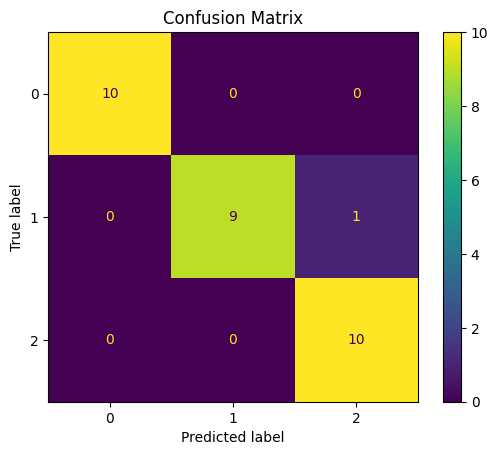

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

# 5. Accuracy

Accuracy measures the proportion of correct predictions.

$$
Accuracy =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

For example, if a model correctly predicts 90 out of 100 observations:

$$
Accuracy = \frac{90}{100} = 0.90
$$

Therefore:

$$
Accuracy = 90\%
$$

### When Accuracy Works Well

Accuracy is useful when:

- Classes are reasonably balanced
- False positives and false negatives have similar importance

### Problem with Accuracy

Accuracy can be misleading when classes are highly imbalanced.

For example:

Suppose 99% of transactions are legitimate and 1% are fraudulent.

A model that always predicts "legitimate" achieves:

$$
Accuracy = 99\%
$$

But it detects:

$$
0\%
$$

of fraudulent transactions.

Therefore, accuracy alone is not sufficient for many imbalanced classification problems.

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


# 6. Precision

Precision measures how many predicted positive cases are actually positive.

$$
Precision =
\frac{TP}
{TP + FP}
$$

In simple terms:

> When the model predicts positive, how often is it correct?

### Example

Suppose the model predicts 100 transactions as fraudulent.

Only 80 are actually fraudulent.

Then:

$$
Precision =
\frac{80}{100}
=
0.80
$$

So precision is:

$$
80\%
$$

### Precision Is Important When

False positives are expensive.

Examples:

- Spam detection
- Fraud investigation
- Medical alerts
- Content moderation

If we want to avoid incorrectly flagging legitimate cases, we care about high precision.

In [30]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.9696969696969696


# 7. Recall

Recall measures how many actual positive cases were correctly identified.

$$
Recall =
\frac{TP}
{TP + FN}
$$

In simple terms:

> Out of all actual positive cases, how many did the model find?

### Example

Suppose there are 100 fraudulent transactions.

The model detects 90 of them.

Then:

$$
Recall =
\frac{90}{100}
=
0.90
$$

So recall is:

$$
90\%
$$

### Recall Is Important When

False negatives are expensive.

Examples:

- Disease detection
- Fraud detection
- Safety systems
- Security threat detection

If missing a positive case is dangerous, recall becomes very important.

In [31]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.9666666666666667


# 8. Precision vs Recall

Precision and recall often have a trade-off.

### High Precision

The model produces relatively few false positives.

### High Recall

The model produces relatively few false negatives.

Consider a disease detection system.

If we make the model very conservative:

- Fewer healthy people are incorrectly diagnosed
- Precision may increase
- But some sick people may be missed
- Recall may decrease

If we make the model more sensitive:

- More sick people are detected
- Recall may increase
- But more healthy people may be incorrectly flagged
- Precision may decrease

Therefore, the appropriate balance depends on the application.

# 9. F1 Score

The F1 score combines precision and recall using their harmonic mean.

$$
F1 =
2
\frac{Precision \times Recall}
{Precision + Recall}
$$

The harmonic mean is used instead of the arithmetic mean because it strongly penalizes situations where one metric is very low.

For example:

$$
Precision = 0.90
$$

$$
Recall = 0.10
$$

The F1 score will remain low.

### When F1 Score Is Useful

F1 is useful when:

- Classes are imbalanced
- Both precision and recall matter
- We want a single metric representing their balance

However, F1 should not automatically be used for every problem.

If false negatives are much more costly than false positives, recall may be more important.

In [32]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 0.9665831244778613


##  Classification Report

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# 11. Specificity

Specificity measures how well the model identifies negative cases.

$$
Specificity =
\frac{TN}
{TN + FP}
$$

It can also be called the True Negative Rate.

Specificity answers:

> Out of all actual negative cases, how many did the model correctly identify as negative?

There is a useful relationship:

$$
False\ Positive\ Rate = 1 - Specificity
$$

Specificity is especially useful when correctly identifying negative cases is important.

# 12. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates a binary classifier across different classification thresholds.

It plots:

$$
True\ Positive\ Rate
$$

against:

$$
False\ Positive\ Rate
$$

where:

$$
TPR =
\frac{TP}{TP + FN}
$$

and:

$$
FPR =
\frac{FP}{FP + TN}
$$

Changing the classification threshold changes the TPR and FPR.

The ROC curve shows this trade-off across many thresholds.

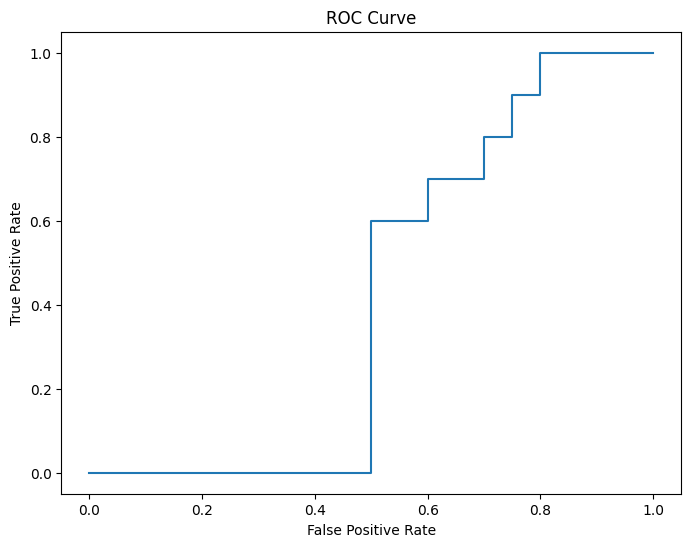

In [34]:
from sklearn.metrics import roc_curve

y_probability = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability,
    pos_label=2
)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

# 13. ROC-AUC

AUC stands for Area Under the Curve.

ROC-AUC summarizes the ROC curve into a single number.

$$
0 \leq AUC \leq 1
$$

A rough interpretation is:

- AUC = 1.0 → Perfect discrimination
- AUC ≈ 0.5 → Random ranking
- AUC < 0.5 → Worse than random ranking

ROC-AUC measures how well the model ranks positive examples above negative examples.

It is therefore different from accuracy.

### Important

ROC-AUC evaluates ranking quality across thresholds.

It does not tell us that the model will achieve a particular accuracy at the default threshold.

In [35]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_probability,
    multi_class="ovr",
    average="weighted"
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 1.0


# 14. Precision-Recall Curve

A Precision-Recall curve shows the relationship between:

- Precision
- Recall

across different classification thresholds.

It is particularly useful for imbalanced classification problems.

For example:

Fraud detection may have:

$$
1\% \text{ fraud}
$$

and:

$$
99\% \text{ legitimate transactions}
$$

In such cases, ROC-AUC can sometimes look overly optimistic.

A Precision-Recall curve focuses directly on the performance of the positive class.

# 15. PR-AUC

PR-AUC represents the area under the Precision-Recall curve.

PR-AUC is especially useful when:

- The positive class is rare
- False positives matter
- We care strongly about identifying positive examples

For highly imbalanced classification, PR-AUC can provide a more informative view of positive-class performance than ROC-AUC.

# 16. Log Loss

Log Loss evaluates the quality of predicted probabilities.

For binary classification:

$$
LogLoss =
-\frac{1}{N}
\sum_{i=1}^{N}
[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
]
$$

A model is penalized heavily when it is confidently wrong.

For example:

Actual class:

$$
y = 1
$$

Prediction A:

$$
p = 0.90
$$

Prediction B:

$$
p = 0.10
$$

Prediction B receives a much larger penalty because the model was confidently wrong.

### Important

For Log Loss:

$$
\text{Lower is better}
$$

Log Loss is useful when the quality of predicted probabilities matters, not just the final predicted class.

In [36]:
from sklearn.metrics import log_loss

probabilities = model.predict_proba(X_test)

loss = log_loss(
    y_test,
    probabilities
)

print("Log Loss:", loss)

Log Loss: 0.15891114914982796


# 17. Regression Evaluation

Regression models predict continuous numerical values.

Examples:

- House prices
- Temperature
- Sales
- Revenue
- Demand
- Delivery time

Common regression metrics include:

- MAE
- MSE
- RMSE
- R²
- Adjusted R²
- MAPE

# 18. Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted values.

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i - \hat{y}_i|
$$

Example:

Actual:

$$
[100, 200, 300]
$$

Predicted:

$$
[110, 190, 280]
$$

Absolute errors:

$$
[10, 10, 20]
$$

Therefore:

$$
MAE =
\frac{10+10+20}{3}
=
13.33
$$

### Advantages

- Easy to understand
- Same unit as the target
- Less sensitive to outliers than MSE

### Disadvantage

MAE does not strongly penalize large errors.

# 21. R² Score

R² measures the proportion of variance in the target that is explained by the model.

$$
R^2 =
1 -
\frac{
\sum (y_i-\hat{y}_i)^2
}{
\sum (y_i-\bar{y})^2
}
$$

where:

$$
\bar{y}
$$

is the mean of the actual target values.

Interpretation:

- R² = 1 → Perfect prediction
- R² = 0 → No improvement over predicting the mean
- R² < 0 → Worse than predicting the mean

R² is useful for understanding explanatory performance, but it should not be used alone.

MAE or RMSE tells us the magnitude of prediction errors in the original target units.

In [37]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

X_regression, y_regression = load_diabetes(
    return_X_y=True
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,   
    test_size=0.2,
    random_state=42
)

regression_model = LinearRegression()

regression_model.fit(
    X_train_reg,
    y_train_reg
)

y_pred_reg = regression_model.predict(
    X_test_reg
)

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 42.79409467959994
MSE : 2900.1936284934795
RMSE: 53.85344583676591
R²  : 0.4526027629719198


# 22. Mean Absolute Percentage Error (MAPE)

MAPE measures the average absolute percentage error.

$$
MAPE =
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
$$

MAPE is easy to interpret because it expresses error as a percentage.

For example:

$$
MAPE = 8\%
$$

means the average absolute percentage error is approximately 8%.

### Problem

MAPE becomes problematic when actual values are zero or very close to zero.

Therefore, MAPE should not be blindly used for every regression problem.

# 23. Cross-Validation

A single train-test split can produce a performance estimate that depends heavily on which observations happen to be placed in the test set.

Cross-validation reduces this problem.

In K-Fold Cross-Validation, the dataset is divided into K folds.

For example:

$$
K = 5
$$

The model is trained and evaluated five times.

Each fold becomes the validation set once.

Conceptually:

Fold 1 → Validation

Fold 2 → Validation

Fold 3 → Validation

Fold 4 → Validation

Fold 5 → Validation

The final score is usually the mean of the five validation scores.

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

X_classification, y_classification = load_iris(
    return_X_y=True
)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X_classification,
    y_classification,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean CV Score: 0.9733333333333334
Standard Deviation: 0.02494438257849294


# 24. Stratified K-Fold Cross-Validation

Stratified K-Fold Cross-Validation is a variation of K-Fold Cross-Validation designed for classification problems.

It tries to preserve the proportion of each class in every fold.

For example, suppose our dataset contains:

$$
80\% \text{ Class A}
$$

and:

$$
20\% \text{ Class B}
$$

Stratified K-Fold attempts to maintain approximately the same class distribution in every fold.

This is especially useful when the classes are imbalanced.

---

## Why Use Stratification?

Consider a classification dataset with:

$$
90\% \text{ Class A}
$$

and:

$$
10\% \text{ Class B}
$$

With ordinary K-Fold, some folds might contain noticeably different class proportions.

Stratified K-Fold reduces this problem by maintaining approximately the same class distribution across folds.

Therefore:

$$
\text{Stratified K-Fold}
\rightarrow
\text{More representative folds}
$$

---

## General Rule

For classification:

$$
\text{StratifiedKFold}
$$

For regression:

$$
\text{KFold}
$$

Stratification is particularly useful when the target classes are imbalanced.

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_classification,
    y_classification,
    cv=cv,
    scoring="accuracy"
)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.96666667 0.96666667 0.93333333 0.96666667 0.9       ]
Mean: 0.9466666666666667
Standard Deviation: 0.02666666666666666


## Understanding the Output

The five values represent the performance obtained on each validation fold.

For example:

$$
[0.97,\ 0.93,\ 0.97,\ 0.97,\ 1.00]
$$

The mean score provides an overall estimate:

$$
Mean =
\frac{Score_1 + Score_2 + \cdots + Score_5}{5}
$$

The standard deviation tells us how much the model's performance varies between folds.

A small standard deviation indicates that the model performs relatively consistently across different folds.

Therefore, it is useful to report both:

$$
\text{Mean CV Score}
$$

and:

$$
\text{Standard Deviation}
$$

# 25. Evaluating a Model with Multiple Metrics

A single metric rarely tells the complete story.

For classification, we may evaluate:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

For regression, we may evaluate:

- MAE
- MSE
- RMSE
- R²

Different metrics answer different questions.

For example:

### Accuracy

How many predictions are correct overall?

### Precision

When the model predicts positive, how often is it correct?

### Recall

How many actual positive cases did the model find?

### F1 Score

How well does the model balance precision and recall?

Therefore:

$$
\boxed{
\text{Model Evaluation}
\neq
\text{One Metric}
}
$$

The appropriate metrics should be selected according to the actual problem.

In [43]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

results = cross_validate(
    model,
    X_classification,
    y_classification,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = results[f"test_{metric}"]
    
    print(
        f"{metric}: "
        f"Mean = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )

accuracy: Mean = 0.9667, Std = 0.0211
precision: Mean = 0.9707, Std = 0.0176
recall: Mean = 0.9667, Std = 0.0211
f1: Mean = 0.9665, Std = 0.0213


## Why Use Multiple Metrics?

Suppose two models produce:

| Model | Precision | Recall |
|---|---:|---:|
| Model A | 0.95 | 0.60 |
| Model B | 0.85 | 0.90 |

Model A has better precision.

Model B has better recall.

Which model is better?

There is no universal answer.

It depends on the application.

If false positives are expensive:

$$
\text{Precision is more important}
$$

If false negatives are expensive:

$$
\text{Recall is more important}
$$

Therefore, metric selection should be driven by the problem rather than simply choosing the metric with the highest value.

# 26. Comparing Multiple Models

Model evaluation is often used to compare different machine learning algorithms.

For example:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- Gradient Boosting

To make a fair comparison, all models should be evaluated using the same:

- Dataset
- Cross-validation strategy
- Evaluation metric

For example:

$$
\text{Model A}
\rightarrow
5\text{-Fold CV}
$$

$$
\text{Model B}
\rightarrow
5\text{-Fold CV}
$$

$$
\text{Model C}
\rightarrow
5\text{-Fold CV}
$$

This allows us to compare their performance more reliably.

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_classification,
        y_classification,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"{name}: "
        f"Mean Accuracy = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )

Logistic Regression: Mean Accuracy = 0.9733, Std = 0.0249
Decision Tree: Mean Accuracy = 0.9533, Std = 0.0340
Random Forest: Mean Accuracy = 0.9667, Std = 0.0211


## Important Principle

The model with the highest accuracy is not automatically the best model.

We should also consider:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Computational cost
- Training time
- Prediction speed
- Interpretability
- Memory requirements
- Robustness

Therefore:

$$
\boxed{
\text{Best Model}
=
\text{Best Model for the Actual Objective}
}
$$

# 27. Hyperparameter Tuning

Hyperparameters are settings that control how a machine learning model is trained.

They are not learned directly from the training data.

Examples include:

### Logistic Regression

Regularization strength:

$$
C
$$

### Decision Tree

Maximum depth:

$$
max\_depth
$$

### Random Forest

Number of trees:

$$
n\_estimators
$$

### K-Nearest Neighbors

Number of neighbors:

$$
k
$$

We can evaluate different hyperparameter combinations and select the configuration that performs best according to our chosen evaluation metric.

## Correct Evaluation Strategy

We should not repeatedly evaluate different hyperparameters on the final test set.

Instead:

$$
Training\ Data
\rightarrow
Cross\ Validation
\rightarrow
Hyperparameter\ Selection
$$

Then, after selecting the final configuration:

$$
Final\ Model
\rightarrow
Test\ Set
$$

The test set should remain untouched until the final evaluation.

# 28. Data Leakage

Data leakage occurs when information that should not be available during training is accidentally used by the model.

Data leakage can produce unrealistically high evaluation scores.

---

## Example

Suppose we have a dataset:

$$
D
$$

We split it into:

$$
D_{train}
$$

and:

$$
D_{test}
$$

The correct procedure is:

$$
Scaler.fit(D_{train})
$$

Then:

$$
Scaler.transform(D_{train})
$$

and:

$$
Scaler.transform(D_{test})
$$

The scaler learns its parameters only from the training data.

---

## Incorrect Approach

If we first scale the entire dataset:

$$
Scaler.fit(D)
$$

and then split the data, information from the test set has influenced the preprocessing.

This is a form of data leakage.

---

## Common Sources of Leakage

- Scaling before train-test splitting
- Imputing missing values using the entire dataset
- Feature selection using the entire dataset
- Using future information to predict the past
- Using test-set information during model selection

Data leakage can make a model appear much better than it actually is.

# 29. Pipeline-Based Evaluation

A Pipeline combines preprocessing and model training into a single workflow.

This is especially useful during cross-validation because preprocessing is performed separately inside each training fold.

For example:

$$
Raw\ Data
\rightarrow
Scaling
\rightarrow
Model
$$

The scaler is fitted only on the training portion of each fold.

This helps prevent preprocessing leakage.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    pipeline,
    X_classification,
    y_classification,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.96666667 1.         0.93333333 0.9        1.        ]
Mean Accuracy: 0.9600000000000002
Standard Deviation: 0.038873012632301994


# 30. Classification Threshold

Many binary classification models produce probabilities.

For example:

$$
P(y=1|x)=0.73
$$

A common default threshold is:

$$
0.5
$$

Therefore:

$$
p \geq 0.5
\Rightarrow
\text{Positive}
$$

and:

$$
p < 0.5
\Rightarrow
\text{Negative}
$$

However, 0.5 is not always the best threshold.

---

## Lower Threshold

If we lower the threshold:

$$
0.5 \rightarrow 0.3
$$

more observations will be classified as positive.

This generally tends to:

- Increase recall
- Increase the number of false positives
- Potentially decrease precision

---

## Higher Threshold

If we increase the threshold:

$$
0.5 \rightarrow 0.8
$$

fewer observations will be classified as positive.

This generally tends to:

- Increase precision
- Increase the number of false negatives
- Potentially decrease recall

Therefore, threshold selection should depend on the cost of different types of errors.

# 31. Probability Calibration

Classification models can produce predicted probabilities.

For example:

$$
P(y=1|x)=0.80
$$

A well-calibrated model means that among observations receiving approximately 0.80 probability, roughly 80% should actually belong to the positive class.

Calibration is important when the probability itself is used for decision-making.

Examples include:

- Risk scoring
- Medical decision support
- Credit risk
- Insurance
- Resource allocation

---

## Classification vs Probability Quality

A model can have good classification accuracy but poorly calibrated probabilities.

Therefore:

$$
\text{Good Accuracy}
\not\Rightarrow
\text{Good Calibration}
$$

When predicted probabilities are important, calibration should be evaluated separately.

# 32. Learning Curves

Learning curves show how model performance changes as the amount of training data increases.

They can help diagnose:

- Underfitting
- Overfitting
- High bias
- High variance
- Whether additional training data may help

We commonly compare:

$$
Training\ Score
$$

with:

$$
Validation\ Score
$$

as the training-set size increases.

---

## Overfitting Pattern

If:

$$
Training\ Score \gg Validation\ Score
$$

the model may be overfitting.

---

## Underfitting Pattern

If both scores are low:

$$
Training\ Score \approx Validation\ Score
$$

the model may be underfitting.

Learning curves therefore provide insight beyond a single evaluation score.

# 33. Practical Model Evaluation Workflow

A reliable model evaluation workflow can be summarized as follows.

---

## Step 1 — Understand the Problem

Determine:

- Classification or regression?
- What is the target?
- What type of errors are costly?

---

## Step 2 — Split the Data

Create training and test sets.

$$
D \rightarrow D_{train} + D_{test}
$$

---

## Step 3 — Establish a Baseline

Start with a simple model or baseline prediction.

---

## Step 4 — Select Appropriate Metrics

For classification:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

For regression:

- MAE
- MSE
- RMSE
- R²

---

## Step 5 — Use Cross-Validation

Estimate how consistently the model performs across different subsets of the training data.

---

## Step 6 — Tune Hyperparameters

Use cross-validation to select appropriate hyperparameters.

---

## Step 7 — Check for Data Leakage

Make sure information from validation or test data has not entered the training process.

---

## Step 8 — Analyze Errors

Study where and why the model makes incorrect predictions.

---

## Step 9 — Final Test Evaluation

After the model and hyperparameters are finalized, evaluate once on the untouched test set.

---

## Step 10 — Monitor After Deployment

Real-world data can change over time.

Therefore, model evaluation should continue after deployment.

# 34. Choosing the Right Evaluation Metric

There is no universally best evaluation metric.

The correct metric depends on the problem.

| Problem | Important Metric |
|---|---|
| Balanced classification | Accuracy |
| Imbalanced classification | F1 / PR-AUC |
| False positives are costly | Precision |
| False negatives are costly | Recall |
| Precision and recall both matter | F1 |
| Probability quality matters | Log Loss |
| Ranking quality matters | ROC-AUC |
| Interpretable regression error | MAE |
| Large errors are especially costly | RMSE |
| Variance explained | R² |

The most important question is:

> What kind of prediction error matters most for this application?

Metric selection should reflect the real objective of the machine learning system.

# 35. Evaluation Metrics Summary

## Classification Metrics

### Accuracy

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Measures the proportion of correct predictions.

---

### Precision

$$
Precision =
\frac{TP}
{TP+FP}
$$

Measures how many predicted positive cases are actually positive.

---

### Recall

$$
Recall =
\frac{TP}
{TP+FN}
$$

Measures how many actual positive cases are correctly detected.

---

### F1 Score

$$
F1 =
2
\frac{Precision \times Recall}
{Precision+Recall}
$$

Balances precision and recall.

---

### Specificity

$$
Specificity =
\frac{TN}
{TN+FP}
$$

Measures how well the model identifies negative cases.

---

### ROC-AUC

Measures the model's ability to distinguish between classes across different classification thresholds.

---

### PR-AUC

Measures the precision-recall trade-off and is particularly useful when the positive class is rare.

---

### Log Loss

Measures the quality of predicted probabilities.

---

# Regression Metrics

### MAE

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
$$

Measures average absolute prediction error.

---

### MSE

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Penalizes large errors more strongly.

---

### RMSE

$$
RMSE =
\sqrt{MSE}
$$

Provides an error measure in the original target units.

---

### R²

$$
R^2 =
1-
\frac{
\sum(y_i-\hat{y}_i)^2
}{
\sum(y_i-\bar{y})^2
}
$$

Measures how much variance is explained relative to predicting the mean.

# 36. Final Mental Model

Model evaluation is much more than calculating accuracy.

A complete evaluation process looks like:

$$
\boxed{
\text{Data Split}
\rightarrow
\text{Training}
\rightarrow
\text{Validation}
\rightarrow
\text{Metric Selection}
\rightarrow
\text{Cross-Validation}
\rightarrow
\text{Hyperparameter Tuning}
\rightarrow
\text{Final Test}
}
$$

Always ask:

1. What is the prediction problem?
2. What types of errors matter?
3. Is the dataset imbalanced?
4. Which metric represents the real objective?
5. Is there any data leakage?
6. Does the model generalize?
7. How stable is the model's performance?
8. Where does the model make mistakes?

The ultimate goal is not to find a model that performs well on one particular dataset split.

The goal is to estimate how well the model will perform on **unseen real-world data**.

# 37. Model Evaluation Checklist

Before declaring a model successful:

- [ ] Training and test data are separated
- [ ] No data leakage exists
- [ ] Appropriate evaluation metrics are selected
- [ ] Baseline performance is established
- [ ] Cross-validation is considered
- [ ] Stratification is used when appropriate
- [ ] Hyperparameters are tuned using validation or cross-validation
- [ ] The test set is kept untouched during model selection
- [ ] Class imbalance is considered
- [ ] Confusion matrix is inspected for classification
- [ ] Multiple metrics are considered
- [ ] Prediction errors are analyzed
- [ ] Final performance is measured on unseen test data
- [ ] Probability calibration is considered when probabilities matter
- [ ] Model performance is monitored after deployment

---

## Final Principle

A high evaluation score does not automatically mean that a model is good.

A good model is one that:

$$
\boxed{
\text{Generalizes Well}
+
\text{Uses Appropriate Metrics}
+
\text{Solves the Actual Problem}
}
$$